# 9강 선형 모델을 이용한 분류
**참고 교재: Bishop (2006) Chapter 4 Linear Models for Classification**

이 장에서는 이전 7강에서 다룬 선형 회귀 모델의 아이디어를 확장하여, 분류(classification) 문제를 해결하기 위한 선형 모델을 살펴본다. 분류의 목표는 입력 벡터 $\mathbf{x}$가 주어졌을 때, 이를 $K$개의 이산 클래스 중 하나로 할당하는 것이다. 예를 들어, $K=2$인 2-클래스 이진 분류(binary classification)의 경우, “클래스 1” 또는 “클래스 2”로 샘플을 분류하는 문제를 다룬다. $K>2$인 다중 클래스(multi-class) 분류 문제의 경우, $K$개의 서로 다른 클래스로 샘플을 분류하게 된다.

회귀(regression)와 달리 분류 문제에서는 목표 변수가 이산적인 클래스 레이블로 표현되므로, 모델이 예측해야 하는 값 또한 0 또는 1(이진 분류)처럼 범주 형태로 해석되어야 한다. 따라서 결정 경계를 직접 학습하는 판별 접근(discriminant approach)을 택하거나, 확률적 관점을 적용하여 클래스 사후확률(posterior probability)을 모델링 할 수 있다.

## 서론: 분류에서의 선형 모델
선형 회귀 모델에서는 입력 $\mathbf{x}$에 대한 여러 feature들에 대해 선형결합을 취한 뒤, 그 결과를 직접 실제값으로 예측하였다. 반면, 분류 문제에서는 예측하고자 하는 대상이 **클래스 레이블**이므로, 선형결합의 출력을 “판별 함수(discriminant function)” 또는 “클래스 소속 확률”로 해석하는 방법이 필요하다.

간단하게는, 선형결합 결과에 임계값(threshold)을 두어 클래스를 구분하는 방법을 생각할 수 있다. 예를 들어, 2-클래스 문제에서 선형결합 결과가 0 이상이면 “클래스 1”, 0 미만이면 “클래스 2”로 분류한다. 이렇게 함으로써 입력 공간에서 결정 경계(decision boundary)는 선형(초평면) 형태가 된다.

## 1. 결정 초평면과 거리

### 1.1 결정 초평면의 정의

**결정 초평면(Decision Hyperplane)**: 선형 분류를 위한 핵심 기준.

이 초평면은 일반적으로 다음과 같은 식으로 표현된다.

$$
\mathbf{w}^T \mathbf{x} + w_0 = 0.
$$

- $\mathbf{w} \in \mathbb{R}^D$는 초평면의 **법선 벡터(normal vector)**  
- $w_0$는 스칼라 **바이어스(bias)** 항
- $\mathbf{x}$는 입력 벡터(예: 2차원 혹은 D차원)

이 때, $\mathbf{w}$가 결정 경계(초평면)에 **수직**으로 놓여 있음을 먼저 증명해보자.

#### 참고: $\mathbf{w}$가 결정 초평면에 수직임을 보이는 증명

초평면 상의 임의의 두 점 $\mathbf{x}_1, \mathbf{x}_2$를 생각해 보자. 이들은 모두

$$
\mathbf{w}^T \mathbf{x}_1 + w_0 = 0, 
\quad
\mathbf{w}^T \mathbf{x}_2 + w_0 = 0
$$

를 만족한다. 두 식을 빼면,

$$
\mathbf{w}^T (\mathbf{x}_2 - \mathbf{x}_1) = 0.
$$

이는 $\mathbf{w}$가 $\mathbf{x}_2 - \mathbf{x}_1$ (즉, 초평면 위 임의의 방향 벡터)와 **수직**임을 의미하므로, $\mathbf{w}$가 결정 초평면의 **법선 벡터**가 된다.



### 1.2 결정 초평면과 한 점 사이의 거리

이제 초평면 $\mathbf{w}^T \mathbf{x} + w_0 = 0$와 임의의 점 $\mathbf{x}^*$ 사이의 **최단 거리**를 계산해 보자.  
최단 거리를 $d$라고 할 때,

$$
d = \frac{|\mathbf{w}^T \mathbf{x}^* + w_0|}{\|\mathbf{w}\|}.
$$

이 공식은 2D 직선/3D 평면/혹은 그 이상의 고차원 초평면에도 동일하게 적용된다. 

---
#### 참고: 점과 직선 사이의 거리

점 $(x_1 , y_1 )$과 직선 $ax+by+c=0$ 사이의 거리 $d$는 다음과 같다:

$$
d=\frac{\vert{ax_1 + by_1 + c}\vert}{\sqrt{a^2 + b^2 }}.
$$

---


## 2. 특정 점과 직선 사이의 거리 시각적 예시

실제로 임의의 한 점을 골라, 결정 직선에 **수직**으로 내린 선분(즉 최단거리)을 그림으로 확인해 보자.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

결정 초평면과 점 [2 3] 사이의 거리 = 2.23606797749979


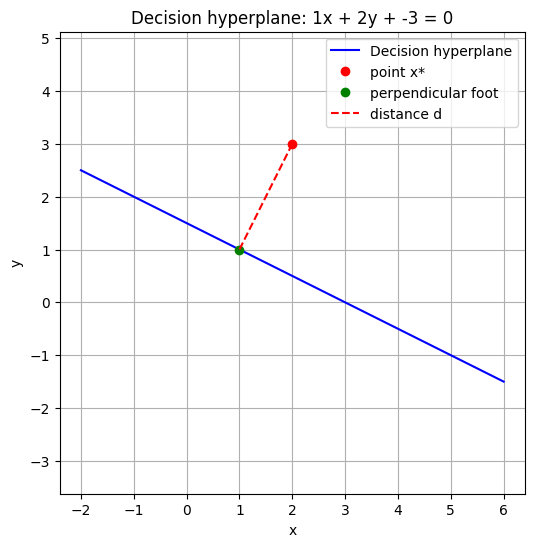

In [2]:
# ----------------------------------------
# 1) 결정 초평면(직선) w^T x + w0 = 0 정의
#    예: w = [1, 2], w0 = -3  =>  x + 2y - 3 = 0
# ----------------------------------------
w = np.array([1, 2])  # 법선 벡터 w
w0 = -3               # 바이어스(상수항) w0

# ----------------------------------------
# 2) 임의의 점 x* 정의
# ----------------------------------------
x_star = np.array([2, 3])  # 예: (2, 3)

# ----------------------------------------
# 3) 점-초평면(직선) 사이의 거리 계산
#    d = |w^T x* + w0| / ||w||
# ----------------------------------------
dist = abs(w.dot(x_star) + w0) / np.linalg.norm(w)
print("결정 초평면과 점", x_star, "사이의 거리 =", dist)

# ----------------------------------------
# 4) 직선을 그리기 위한 y = (-w0 - w[0]*x) / w[1] 형태로 변환
#    w[0]*x + w[1]*y + w0 = 0
#    => y = - (w[0]/w[1]) * x - (w0 / w[1])
# ----------------------------------------
def line_equation(x, w, w0):
    return -(w[0]/w[1])*x - (w0/w[1])

# 직선을 그릴 x 범위 설정
x_vals = np.linspace(-2, 6, 100)
y_vals = line_equation(x_vals, w, w0)

# ----------------------------------------
# 5) 점 x_star에서 직선으로의 수직 내린 점(수선의 발) 좌표 구하기
#
#   결정 초평면: w^T x + w0 = 0
#   점: x_star
#   수선의 발: x_foot
#
#   x_foot는 다음을 만족:
#     1) w^T x_foot + w0 = 0 (직선 위)
#     2) x_foot - x_star가 w와 평행 (법선 방향)
#
#   → x_foot = x_star - ((w^T x_star + w0) / ||w||^2) * w
# ----------------------------------------
w_norm_sq = w.dot(w)  # ||w||^2
x_foot = x_star - ((w.dot(x_star) + w0) / w_norm_sq) * w

# ----------------------------------------
# 6) 시각화
# ----------------------------------------
plt.figure(figsize=(6,6))

# 결정 초평면(직선) 그리기
plt.plot(x_vals, y_vals, 'b-', label='Decision hyperplane')

# 임의의 점 x_star 표시
plt.plot(x_star[0], x_star[1], 'ro', label='point x*')

# 수선의 발 x_foot 표시 및 연결선 그리기
plt.plot(x_foot[0], x_foot[1], 'go', label='perpendicular foot')
plt.plot([x_star[0], x_foot[0]], [x_star[1], x_foot[1]], 'r--', label='distance d')

# 그래프 설정
plt.title(f"Decision hyperplane: {w[0]}x + {w[1]}y + {w0} = 0")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


## 3. Fisher의 선형 판별 분석 (Linear Discriminant Analysis, LDA)
**이진 분류(binary classification)**: 클래스가 두 개라 가정하고, 각 클래스를 $C_1, C_2$라고 해보자.

LDA는 **두 개의 클래스**가 주어졌을 때, 고차원 공간에서 **한 줄(1차원)로 데이터를 투영**시켜 각 클래스를 가장 잘 구분되도록 만드는 방법이다.


### 3.1 LDA의 목표

- 각 클래스에 속하는 데이터 포인트: 
  $$
    \{ \mathbf{x}_n \mid \mathbf{x}_n \in C_i \}, \quad i \in \{ 1, 2\}.
  $$
- 각 클래스의 평균 벡터(평균 좌표):
  $$
    \mathbf{m}_1 = \frac{1}{N_1}\sum_{n \in C_1}\mathbf{x}_n, \quad \mathbf{m}_2 =\frac{1}{N_2}\sum_{n \in C_2}\mathbf{x}_n.
  $$

**프로젝션 벡터 $\boldsymbol{w}$**:

우리는 데이터 $\mathbf{x}$를 **1차원** 축 $\boldsymbol{w}$ 방향으로 사영(projection)해서,  
$$
y = \boldsymbol{w}^T \mathbf{x}
$$
로 변환하고 싶다. 그런데 이 때,

1. 클래스 1과 클래스 2의 **투영된 평균값** $m_1, m_2$이 서로 최대한 멀어지도록(즉 $(m_2 - m_1)^2 $가 커지도록)  
2. 클래스 1 내부 데이터의 변동성과 클래스 2 내부 데이터의 변동성을 더한 값( $N_1 s_1^2 + N_2 s_2^2$ )은 작아지도록  

하고 싶다.  
이를 하나의 성능 지표(Performance Index)로 표현하면,

$$
\text{PI}_{\text{LDA}}(\boldsymbol{w})
= \frac{(m_2 - m_1)^2}{N_1 s_1^2 + N_2 s_2^2}.
$$

여기서,

- $ m_i = \boldsymbol{w}^T \mathbf{m}_i $ : 클래스 $i$의 평균 $\mathbf{m}_i$를 $\boldsymbol{w}$에 사영한 값.
- $ s_i^2 $ : 클래스 $i$에 속한 데이터들을 $\boldsymbol{w}$에 사영했을 때의 표본분산.  $s_i^2 = \frac {1}{N_i}\sum_{n \in C_i} (y_n - m_i )^2$. 여기서, $y_n = \boldsymbol{w}^T \mathbf{x}_n$.
- $ N_i $ : 클래스 $i$의 데이터 개수.

### 3.2 LDA 공식 유도

#### 3.2.1 Between-class scatter (클래스 간 산포 행렬) $S_B$
성능 지표 $\text{PI}_{\text{LDA}}(\boldsymbol{w})$의 분자 부분을 보자.
$$
\begin{align}
(m_2 - m_1)^2 
&= \bigl(\boldsymbol{w}^T (\mathbf{m}_2 - \mathbf{m}_1)\bigr)^2 \\
&= \boldsymbol{w}^T (\mathbf{m}_2 - \mathbf{m}_1)(\mathbf{m}_2 - \mathbf{m}_1)^T \boldsymbol{w}.
\end{align}
$$

여기서, 클래스 간 산포 행렬 $S_B \;=\; (\mathbf{m}_2 - \mathbf{m}_1)(\mathbf{m}_2 - \mathbf{m}_1)^T$로 정의하여, 위 식을

$$
\boldsymbol{w}^T S_B \boldsymbol{w}.
$$
로 표현할 수 있다.



#### 3.2.2 Within-class scatter (클래스 내 산포 행렬) $S_W$
성능 지표 $\text{PI}_{\text{LDA}}(\boldsymbol{w})$의 분모 부분을 보자.

$$
\begin{align}
N_1 s_1^2 + N_2 s_2^2 &= \sum_{i=1}^2  \sum_{n \in C_i} (y_n - m_i )^2 \\
&= \sum_{i=1}^2  \sum_{n \in C_i}  (\boldsymbol{w}^T \mathbf{x}_n - \boldsymbol{w}^T \mathbf{m}_i )^2 \\
&=\sum_{i=1}^2  \sum_{n \in C_i}  \boldsymbol{w}^T (\mathbf{x}_n - \mathbf{m}_i ) (\mathbf{x}_n - \mathbf{m}_i )^T \boldsymbol{w} .
\end{align}
$$

여기서, 클래스 내 산포 행렬 $S_W \;=\;  \sum_{i=1}^2 \sum_{n \in C_i} (\mathbf{x}_n - \mathbf{m}_i)(\mathbf{x}_n - \mathbf{m}_i)^T$로 정의하여, 위 식을

$$
\boldsymbol{w}^T S_W \boldsymbol{w}.
$$
로 표현할 수 있다.


#### 3.2.3 LDA의 성능 지표(목적함수)를 이용한 최적화

결과적으로,
$$
\text{PI}_{\text{LDA}}(\boldsymbol{w})
= \frac{\boldsymbol{w}^T S_B \boldsymbol{w}}{\boldsymbol{w}^T S_W \boldsymbol{w}}.
$$

이를 최대화하는 $\boldsymbol{w}$를 찾고 싶다.

**최적 $\boldsymbol{w}_{\text{LDA}}$**:

위 식을 $\boldsymbol{w}$에 대해 벡터미분하고 0벡터가 나오는(즉, $\text{PI}_{\text{LDA}}$를 최대화하는) $\boldsymbol{w}$를 구하면 다음과 같다.

$$
\boldsymbol{w}_{\text{LDA}}
\propto S_W^{-1} (\mathbf{m}_2 - \mathbf{m}_1).
$$



---
#### 참고: Rayleigh Quotient
**기본 정의**

행렬 $A \in \mathbb{R}^{n \times n}$가 **대칭**(symmetric)이라고 하자.  
그렇다면, 다음과 같은 **Rayleigh Quotient**가 있다:

$$
\frac{\mathbf{x}^T A \mathbf{x}}{\mathbf{x}^T \mathbf{x}}
\quad\in\quad
[\lambda_{\min}(A),\,\lambda_{\max}(A)].
$$

- 최대값(= $\lambda_{\max}(A)$)을 달성하는 $\mathbf{x}$는 $A$의 **최대 고유값**에 대응하는 **고유벡터(eigenvector)** 방향이다.  
- 최소값은 $\lambda_{\min}(A)$에 해당하며, 그에 대응하는 고유벡터 방향에서 달성된다.

**Rayleigh Quotient**

$$
\frac{\mathbf{x}^T A \mathbf{x}}{\mathbf{x}^T B \mathbf{x}}
\quad
(A, B \in \mathbb{R}^{n \times n},\; A = A^T,\; B \succ 0)
$$

- $B$가 양의 정부호(positive definite)이므로, $B^{-1}$이 존재한다.  
- 이 비율 역시 **$\lambda_{\min}(B^{-1}A)$부터 $\lambda_{\max}(B^{-1}A)$** 사이에 있으며, 최대값은 $B^{-1}A$의 최대 고유값에 해당하는 고유벡터 방향에서 달성된다:

$$
\max_{\mathbf{x}\neq 0}
\frac{\mathbf{x}^T A \mathbf{x}}{\mathbf{x}^T B \mathbf{x}}
=
\lambda_{\max}\bigl(B^{-1}A\bigr).
$$



**Fisher의 LDA 목적함수와 Rayleigh Quotient**


Fisher의 선형 판별 분석(LDA)에서 두 클래스(1, 2)를 생각해보면,  
- **클래스 간 분산** 행렬 $S_B = (\mathbf{m}_2 - \mathbf{m}_1)(\mathbf{m}_2 - \mathbf{m}_1)^T$  
- **클래스 내 분산** 행렬 $S_W$ (양의 정부호라고 가정)  

우리가 최대화하고자 하는 목적함수는:

$$
\max_{\mathbf{w}}
\frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}
.
$$

이는 곧 **일반화된 Rayleigh Quotient** 형태와 동일하다.  
$$
\text{(여기서 }A = S_B,\; B = S_W,\; \mathbf{x} = \mathbf{w}\text{)}
$$

결과적으로 최적 $\mathbf{w}$는  
$$
S_W^{-1} S_B
$$
의 **최대 고유값**에 해당하는 고유벡터와 동일한 방향이 된다.

---

#### 3.2.4 $\boldsymbol{w}_{\text{LDA}} \propto S_W^{-1}(\mathbf{m}_2 - \mathbf{m}_1)$ 유도 과정

$$
\text{PI}_{\text{LDA}}(\boldsymbol{w})
= \frac{\boldsymbol{w}^T S_B \boldsymbol{w}}{\boldsymbol{w}^T S_W \boldsymbol{w}}
$$
를 최대화할 때,  
$$
\boldsymbol{w}_{\text{LDA}}
\propto S_W^{-1} (\mathbf{m}_2 - \mathbf{m}_1)
$$
임을 보이는 유도 과정을 살펴보자.

**문제 정의: Rayleigh quotient 최적화**

LDA에서 우리가 최적화하려는 목적함수(성능 지표)는
$$
\text{PI}_{\text{LDA}}(\boldsymbol{w})
= \frac{\boldsymbol{w}^T S_B \boldsymbol{w}}{\boldsymbol{w}^T S_W \boldsymbol{w}}
$$
이다. 이와 같은 형태는 **Rayleigh quotient**(레이리 몫)이라 불리며, 다음과 같은 중요한 성질을 갖는다.

- $\boldsymbol{w}$에 임의의 상수 $c$를 곱해도 함수값이 변하지 않는다.
  $$
  \text{PI}_{\text{LDA}}(c \boldsymbol{w}) 
  = \frac{ (c\boldsymbol{w})^T S_B (c\boldsymbol{w}) }{ (c\boldsymbol{w})^T S_W (c\boldsymbol{w}) }
  = \frac{ c^2(\boldsymbol{w}^T S_B \boldsymbol{w}) }{ c^2(\boldsymbol{w}^T S_W \boldsymbol{w}) }
  = \text{PI}_{\text{LDA}}(\boldsymbol{w}).
  $$
  따라서 크기는 중요치 않고, $\boldsymbol{w}$의 방향(direction)만을 결정하면 된다.

**라그랑주 승수를 이용한 최적화 (Lagrangian):**

$\boldsymbol{w}^T S_W \boldsymbol{w} \neq 0$라는 제약(분모가 0이 되면 안 됨)을 고려하며 최적화를 수행하려면, 라그랑주 승수법(Lagrange multiplier method)을 사용할 수 있다.

목적함수를 직접 최적화하기보다는, 제약 조건 $\boldsymbol{w}^T S_W \boldsymbol{w} = 1$ (또는 임의의 상수)로 둔 상태에서, 다음과 같은 라그랑지언(Lagrangian)을 정의한다.

$$
L(\boldsymbol{w}, \lambda) 
= \boldsymbol{w}^T S_B \boldsymbol{w} 
  \;-\; \lambda \bigl(\boldsymbol{w}^T S_W \boldsymbol{w} - 1\bigr).
$$

여기서 $\lambda$는 라그랑주 승수이다. 이 함수를 $\boldsymbol{w}$에 대해 미분하여 0벡터가 되도록 하는 $\boldsymbol{w}$를 찾으면, 우리가 원하는 최적해(또는 그 방향)를 찾을 수 있다.

**라그랑지언 미분 및 정리:**

$$
L(\boldsymbol{w}, \lambda) 
= \boldsymbol{w}^T S_B \boldsymbol{w} - \lambda \left(\boldsymbol{w}^T S_W \boldsymbol{w} - 1\right).
$$

이를 $\boldsymbol{w}$로 미분하면,

$$
\begin{align}
\frac{\partial L}{\partial \boldsymbol{w}} 
&= \frac{\partial}{\partial \boldsymbol{w}}
  \left(\boldsymbol{w}^T S_B \boldsymbol{w}\right)
  \;-\; \lambda \frac{\partial}{\partial \boldsymbol{w}}
             \left(\boldsymbol{w}^T S_W \boldsymbol{w} - 1\right) \\
  &= 2 S_B \boldsymbol{w} 
  \;-\; \lambda \, 2 S_W \boldsymbol{w} \\
  &=\mathbf{0}.
\end{align}
$$

즉,

$$
S_B \boldsymbol{w} 
= \lambda \, S_W \boldsymbol{w}.
$$
이것이 우리가 풀어야 하는 고유 벡터(eigenvector) 형태의 방정식이 된다.

**$S_B \boldsymbol{w}$와 $(\mathbf{m}_2 - \mathbf{m}_1)$의 관계:**

$S_B$는
$$
S_B = (\mathbf{m}_2 - \mathbf{m}_1)(\mathbf{m}_2 - \mathbf{m}_1)^T
$$
이므로, 임의의 $\boldsymbol{w}$에 대해
$$
S_B \boldsymbol{w} 
= (\mathbf{m}_2 - \mathbf{m}_1)(\mathbf{m}_2 - \mathbf{m}_1)^T \boldsymbol{w}.
$$
우변을 다시 살펴보면, 
$$
(\mathbf{m}_2 - \mathbf{m}_1)^T \boldsymbol{w}
$$
은 **스칼라**이다. 따라서
$$
S_B \boldsymbol{w}
= (\mathbf{m}_2 - \mathbf{m}_1) 
    \underbrace{(\mathbf{m}_2 - \mathbf{m}_1)^T \boldsymbol{w}}_{\text{스칼라}}
= \Bigl((\mathbf{m}_2 - \mathbf{m}_1)^T \boldsymbol{w}\Bigr)\,
  (\mathbf{m}_2 - \mathbf{m}_1).
$$
즉, $S_B \boldsymbol{w}$는 $(\mathbf{m}_2 - \mathbf{m}_1)$ 방향 벡터가 된다.

결국,
$$
S_B \boldsymbol{w} 
= \lambda S_W \boldsymbol{w}
\quad \Longrightarrow \quad
(\mathbf{m}_2 - \mathbf{m}_1)(\mathbf{m}_2 - \mathbf{m}_1)^T \boldsymbol{w}
= \lambda S_W \boldsymbol{w}.
$$
좌변은 $(\mathbf{m}_2 - \mathbf{m}_1)$ 방향 벡터이므로, 자연스럽게 $\boldsymbol{w}$는 
$$
\boldsymbol{w} \propto S_W^{-1}(\mathbf{m}_2 - \mathbf{m}_1)
$$
의 형태가 되어야 함을 알 수 있다.

즉, $\boldsymbol{w}$의 **방향**만이 의미가 있고, **크기**(norm)는 목적함수에 영향을 주지 않기 때문에, “비례한다”라고 표현하게 된다.



## 4. 예제: Fisher의 LDA

### 4.1 이변량 정규분포 데이터 생성

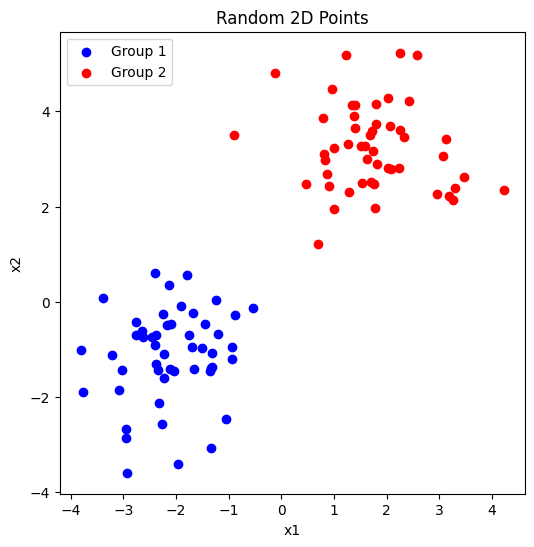

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# 두 개의 서로 다른 이변량 정규분포 샘플링
mean1 = [-2, -1]
cov1 = [[1.0, 0.3],
        [0.3, 1.0]]  # 임의의 공분산 행렬

mean2 = [2, 3]
cov2 = [[1.0, -0.2],
        [-0.2, 1.0]]

N = 50  # 각 그룹별 점 개수
X1 = np.random.multivariate_normal(mean1, cov1, N)
X2 = np.random.multivariate_normal(mean2, cov2, N)

# 간단한 산점도 시각화
plt.figure(figsize=(6,6))
plt.scatter(X1[:,0], X1[:,1], c='blue', label='Group 1')
plt.scatter(X2[:,0], X2[:,1], c='red', label='Group 2')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Random 2D Points")
plt.legend()
plt.show()


### 4.2 $ S_B $와 $ S_W $ 계산

In [4]:
m1 = np.mean(X1, axis=0)  # (2,) vector
m2 = np.mean(X2, axis=0)  # (2,) vector

print("m1 =", m1)
print("m2 =", m2)

# 클래스 내 산포
S1 = np.zeros((2,2))
for x in X1:
    diff = (x - m1).reshape(-1,1)
    S1 += diff @ diff.T

S2 = np.zeros((2,2))
for x in X2:
    diff = (x - m2).reshape(-1,1)
    S2 += diff @ diff.T

S_W = S1 + S2
print("\nS_W =\n", S_W)

# 클래스 간 산포
m_diff = (m2 - m1).reshape(-1,1)
S_B = m_diff @ m_diff.T
print("\nS_B =\n", S_B)


m1 = [-2.10123557 -1.1207998 ]
m2 = [1.7491915  3.23813303]

S_W =
 [[72.68578613 -0.63064329]
 [-0.63064329 84.90896851]]

S_B =
 [[14.82578867 16.78375298]
 [16.78375298 19.00029538]]


### 4.3 LDA 해: $\mathbf{w}_{\text{LDA}}= S_W^{-1} (\mathbf{m}_2 - \mathbf{m}_1)$


In [5]:
S_W_inv = np.linalg.inv(S_W)
w_LDA = S_W_inv @ (m2 - m1)
print("w_LDA =", w_LDA)


w_LDA = [0.05342244 0.05173333]


### 4.4 1D 투영(Projection) 및 히스토그램

- 각각의 데이터 포인트 $\mathbf{x}$를 $y = \mathbf{w}_{\text{LDA}}^T \mathbf{x}$로 사영  
- 클래스 1, 2이 1D상에서 어떻게 분포하는지 확인


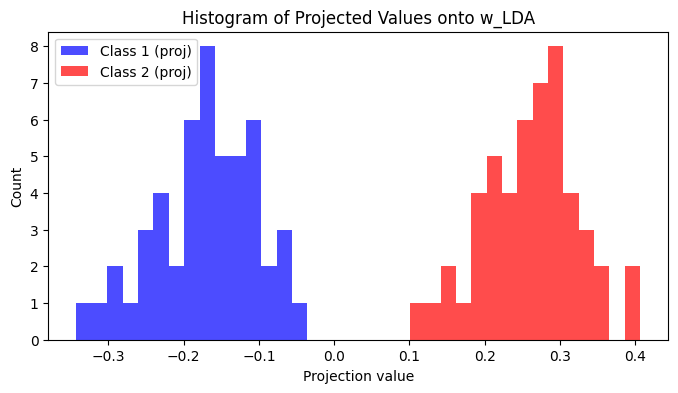

In [7]:
y1 = X1 @ w_LDA  
y2 = X2 @ w_LDA  

plt.figure(figsize=(8,4))
plt.hist(y1, bins=15, alpha=0.7, color='blue',  label='Class 1 (proj)')
plt.hist(y2, bins=15, alpha=0.7, color='red',  label='Class 2 (proj)')
plt.title("Histogram of Projected Values onto w_LDA")
plt.xlabel("Projection value")
plt.ylabel("Count")
plt.legend()
plt.show()


## 5. 정리: Fisher's LDA (이진 분류) 

- **Fisher의 LDA**는
  $$
  \max_{\mathbf{w}}
  \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}
  $$
  라는 **일반화된 Rayleigh Quotient** 최적화 문제와 동일.
- 해는
  $$
  \mathbf{w}_{\text{LDA}}
  \;\propto\;
  S_W^{-1}(\mathbf{m}_1 - \mathbf{m}_0).
  $$
- 2D 예시로 실제 계산해보면, 데이터가 LDA 축에 사영되었을 때 클래스가 (비교적) 잘 분리되는 것을 확인 가능.
- 실제로는 역행렬 존재 여부(샘플 수 대비 차원 수)나, 다중 클래스 확장, 정규화/스케일링 등 다양한 실무적 이슈가 존재하지만, 본 예시로 **핵심 아이디어**를 살펴볼 수 있다.


## 6. 다중 클래스로의 확장 (Multi-class LDA)

앞서 설명한 **피셔의 선형 판별**은 이진 분류 문제에서 클래스 간 산포(between-class scatter)를 크게 하고,  클래스 내부 산포(within-class scatter)를 작게 만드는 투영(projection) 방향을 찾는 기법으로 소개되었다.

이를 더 확장하면, $ K > 2 $개의 클래스를 다루는 경우에도 유사한 아이디어로  **투영(projection) 공간**을 찾는 것이 가능하다.


### 6.1 진행 방향

- **각 클래스별로**  
  - 클래스 평균 벡터$\left(\mathbf{m}_k = \frac{1}{N_k}\sum_{n \in C_k}\mathbf{x_n} \right)$
  - 클래스 내부 공분산 행렬$\left( \mathbf{S}_{k} = \sum_{n \in C_k } (\mathbf{x}_n - \mathbf{m}_k )(\mathbf{x}_n - \mathbf{m}_k )^T \right) $  
  등을 정의한다.

- **전체 데이터**에 대해서도  
  - 전체 평균$\left(\mathbf{m} = \frac{1}{N}\sum_{n=1}^N \mathbf{x}_n = \frac{1}{N}\sum_{k=1}^{K} N_k \mathbf{m}_k \right)$,  
  - 전체 공분산 $\left(\mathbf{S}_T = \sum_{n=1}^N (\mathbf{x}_n - \mathbf{m}) (\mathbf{x}_n - \mathbf{m}) ^T \right)$ 등을 구해둔 뒤, 이를 바탕으로
  - 클래스 간 산포 행렬(between-class scatter) $\left(\mathbf{S}_B = \sum_{k=1}^K N_k (\mathbf{m}_k -\mathbf{m})(\mathbf{m}_k - \mathbf{m})^T \right)$  
  - 클래스 내부 산포 행렬(within-class scatter) $\left(\mathbf{S}_W = \sum_{k=1}^K \mathbf{S}_k \right)$  를 유도한다 (참고: $ \mathbf{S}_T = \mathbf{S}_W + \mathbf{S}_B $).

- **목적**  
  - 2-클래스 LDA(피셔 판별)에서와 마찬가지로,  
    $$
    \max_{\mathbf{W}} \quad \frac{\text{trace}(\mathbf{W}^T \mathbf{S}_B \mathbf{W})}{\text{trace}(\mathbf{W}^T \mathbf{S}_W \mathbf{W})}
    $$
    의 형태(또는 유사한 Rayleigh quotient 형태)의 기준 함수를 세워,   “클래스 간 산포 대비 클래스 내부 산포를 최대로 하는” 선형 변환 $\mathbf{W}$를 찾는다 ($\mathbf{W}$는 행렬).

### 6.2 투영 차원
- **2-클래스 문제**에서는 1차원 축으로 투영만 하면 (이론적으로) 충분했다.
- **다중 클래스 문제**에서는 $K-1$차원을 고려한다.
- 실제로는 $\mathbf{S}_W^{-1}\mathbf{S}_B$의 고유분해(eigen-decomposition)를 통해,
    **상위 $K-1$개의 고유값**에 대응하는 고유벡터들을 선택해 투영 공간을 구성하는 것이 일반적이다.
  

### 6.3 최적화와 해법
1. **고유벡터(eigenvector) 계산**  
   - 보통 “$\mathbf{S}_W^{-1} \mathbf{S}_B$” 연산을 수행하여,  
     $$
     \mathbf{S}_W^{-1} \mathbf{S}_B \, \mathbf{w} = \lambda \, \mathbf{w}
     $$
     를 만족하는 고유벡터 $\mathbf{w}$와 고유값 $\lambda$를 구한다.
   - 이 중 고유값 $\lambda$가 큰 방향($\mathbf{w}$)이 “클래스 간 산포는 크게, 클래스 내 산포는 작게 만들어주는” 방향이라고 해석할 수 있다.

2. **투영행렬 $\mathbf{W}$** 구성  
   - 위에서 구한 고유벡터들을 열(column)로 모아서 행렬 $\mathbf{W} = [\mathbf{w}_1, \mathbf{w}_2, \dots, \mathbf{w}_m]$ 를 구성한다.
   - 보통은 고유값이 가장 큰 순서대로 $K-1$개(또는 더 적은 수)를 선택하여 열벡터를 채우는 방식을 사용.
   - 새로운 입력 $\mathbf{x}$에 대해서는 $\mathbf{z} = \mathbf{W}^T \mathbf{x}$로 보다 낮은 차원의 공간으로 투영하게 된다.



### 6.4 해석
- **2-클래스 LDA와 동일한 원리**  
  - 본질은 “클래스 간 산포(between-class scatter)는 크게, 클래스 내부 산포(within-class scatter)는 작게”하는 것이며, 다중 클래스로 확장되어도 이 원리는 바뀌지 않는다.
  - 단지 클래스 수가 늘어남에 따라 $\mathbf{S}_B$와 $\mathbf{S}_W$의 정의가 확장되었고, 1차원이 아닌 $K-1$차원 이상으로 투영해야 더 풍부하게 클래스를 구분할 수 있게 되었을 뿐이다.

- **투영 후 분류**  
  - 투영행렬 $\mathbf{W}$를 통해 구한 저차원 좌표 $\mathbf{z} = \mathbf{W}^T \mathbf{x}$를 사용하면, 차원 축소와 동시에 선형 판별 기반의 분류를 수행하기 용이해진다.

- **차원 축소 + 분류**  
  - 다중 클래스 LDA는 “분류 성능을 높이기 위한 방향”으로 차원을 줄인다는 점에서, 다른 차원 축소 기법(PCA 등)과 비교했을 때 **분류 지향적**(supervised)인 특징을 갖는다.
  - PCA는 “분산(variance)을 최대화”하는 축을 찾지만, 클래스 레이블 정보를 사용하지 않는 반면,
  - LDA는 클래스 레이블 정보를 적극적으로 사용하여 **분류에 유리한** 축(또는 공간)을 찾는다.




### 6.5 요약

- **다중 클래스 LDA(Multi-class LDA)**:  
  1) 클래스 간 산포 $\mathbf{S}_B$와 클래스 내부 산포 $\mathbf{S}_W$를 계산한다.  
  2) $\mathbf{S}_W^{-1} \mathbf{S}_B$의 **고유벡터**를 찾는다.  


- **핵심 아이디어**: 2-클래스 LDA(피셔 판별)의 “클래스 간 분산/클래스 내부 분산 최대화”를 다중 클래스로 일반화한 것.

- **의의**: 분류 관점에서 유리한 방식으로 차원 축소를 수행할 수 있다(‘지도학습적(supervised) 차원 축소’).

- **주의**: $\mathbf{S}_W$가 풀랭크가 아닐 때, 샘플 불균형이 극심할 때, 데이터 분포가 비선형 구조를 가질 때 등은 추가 기법(regularization 등)이 필요할 수 있음.